Install Packages

In [ ]:
!pip install transformers datasets accelerate -q

Upload Files

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving test.xlsx to test.xlsx
Saving train.xlsx to train.xlsx


Load Dataset

In [ ]:
import pandas as pd

train_df = pd.read_excel("train.xlsx")
test_df = pd.read_excel("test.xlsx")

# Ensure 'text' column exists
if "text" not in train_df.columns:
    train_df.rename(columns={train_df.columns[0]: "text"}, inplace=True)

if "text" not in test_df.columns:
    test_df.rename(columns={test_df.columns[0]: "text"}, inplace=True)

print("\n=== TRAIN DATA SAMPLE ===") # Member Data
print(train_df.head())


=== TRAIN DATA SAMPLE ===
                                                text
0  Name: John | ID: 1001 | Role: Student | Action...
1  Name: Mary | ID: 1002 | Role: Admin | Action: ...
2  Name: Alex | ID: 1003 | Role: Student | Action...
3  Name: Sara | ID: 1004 | Role: Staff | Action: ...
4  Name: David | ID: 1005 | Role: Student | Actio...


Load Falcon Model

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "tiiuae/falcon-rw-1b"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto"
)

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.word_embeddings.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Tokenization

In [ ]:
example_text = train_df["text"].iloc[0]

tokens = tokenizer.tokenize(example_text)
encoded = tokenizer(
    example_text,
    padding="max_length",
    truncation=True,
    max_length=64
)

print("\n=== TOKENIZATION SAMPLE ===")
print("Original Text:\n", example_text)

print("\nTokens:\n", tokens)

print("\nInput IDs (first 20):\n", encoded["input_ids"][:20])

print("\nAttention Mask (first 20):\n", encoded["attention_mask"][:20])


=== TOKENIZATION SAMPLE ===
Original Text:
 Name: John | ID: 1001 | Role: Student | Action: Login

Tokens:
 ['Name', ':', 'ĠJohn', 'Ġ|', 'ĠID', ':', 'Ġ100', '1', 'Ġ|', 'ĠRole', ':', 'ĠStudent', 'Ġ|', 'ĠAction', ':', 'ĠLogin']

Input IDs (first 20):
 [5376, 25, 1757, 930, 4522, 25, 1802, 16, 930, 20934, 25, 13613, 930, 7561, 25, 23093, 50256, 50256, 50256, 50256]

Attention Mask (first 20):
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0]


Training Function

In [ ]:
from datasets import Dataset
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling

def train_model(df):
    dataset = Dataset.from_pandas(df)

    def tokenize(example):
        return tokenizer(
            example["text"],
            truncation=True,
            padding="max_length",
            max_length=64
        )

    dataset = dataset.map(tokenize, batched=True)
    dataset.set_format(type="torch", columns=["input_ids", "attention_mask"])

    data_collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer,
        mlm=False
    )

    training_args = TrainingArguments(
        output_dir="./falcon_model",
        num_train_epochs=3,
        per_device_train_batch_size=2,
        logging_steps=10,
        save_strategy="no",
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset,
        data_collator=data_collator
    )

    trainer.train()
    return model

Compute Loss

In [ ]:
import torch
import numpy as np

def compute_losses(model, df):
    model.eval()
    losses = []

    for i, text in enumerate(df["text"]):
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding="max_length",
            max_length=64
        ).to(model.device)

        with torch.no_grad():
            outputs = model(**inputs, labels=inputs["input_ids"])

        loss = outputs.loss.item()
        losses.append(loss)

        if i < 3:
            print("\nText:", text)
            print("Loss:", loss)

    return losses

Metrics

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

def evaluate(train_losses, test_losses):
    threshold = (np.mean(train_losses) + np.mean(test_losses)) / 2

    y_true = [1]*len(train_losses) + [0]*len(test_losses)
    y_pred = [(l < threshold) for l in train_losses + test_losses]

    ASR = accuracy_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    FPR = fp / (fp + tn)

    avg_loss = np.mean(test_losses)

    return ASR, FPR, avg_loss

Run Experiment

In [ ]:
print("\n=== FALCON BASELINE ===")

model = train_model(train_df)

print("\n--- TRAIN LOSSES ---")
train_losses = compute_losses(model, train_df)

print("\n--- TEST LOSSES ---")
test_losses = compute_losses(model, test_df)

ASR, FPR, loss = evaluate(train_losses, test_losses)

print("\n=== FINAL RESULTS ===")
print("ASR:", ASR)
print("FPR:", FPR)
print("Average Loss:", loss)


=== FALCON BASELINE ===


Map:   0%|          | 0/10 [00:00<?, ? examples/s]

Step,Training Loss
10,1.469390



--- TRAIN LOSSES ---

Text: Name: John | ID: 1001 | Role: Student | Action: Login
Loss: 14.389514923095703

Text: Name: Mary | ID: 1002 | Role: Admin | Action: Upload
Loss: 14.934791564941406

Text: Name: Alex | ID: 1003 | Role: Student | Action: Download
Loss: 14.766730308532715

--- TEST LOSSES ---

Text: Name: Henry | ID: 2001 | Role: Student | Action: Login
Loss: 15.187098503112793

Text: Name: Evelyn | ID: 2002 | Role: Admin | Action: Upload
Loss: 15.50967025756836

Text: Name: Alexander | ID: 2003 | Role: Student | Action: Download
Loss: 15.409488677978516

=== FINAL RESULTS ===
ASR: 0.8
FPR: 0.2
Average Loss: 15.31156940460205


# Implementing Defence (Sanitisation, Augmentation and DP)

**Sanitisation**

Apply Sanitisation

In [ ]:
import re

def sanitise(text):
    text = re.sub(r"Name:\s*[^|]+", "Name: [REDACTED]", text)
    text = re.sub(r"ID:\s*\d+", "ID: [REDACTED]", text)
    return text

train_df_san = train_df.copy()
test_df_san = test_df.copy()

train_df_san["text"] = train_df_san["text"].apply(sanitise)
test_df_san["text"] = test_df_san["text"].apply(sanitise)

print("\n--- SANITISATION SAMPLE ---")
print("Original :", train_df["text"].iloc[0])
print("Sanitised:", train_df_san["text"].iloc[0])


--- SANITISATION SAMPLE ---
Original : Name: John | ID: 1001 | Role: Student | Action: Login
Sanitised: Name: [REDACTED]| ID: [REDACTED] | Role: Student | Action: Login


Train + Evaluate

In [ ]:
print("\n=== SANITISATION MODEL ===")

san_model = train_model(train_df_san)

print("\n--- TRAIN LOSSES ---")
train_losses_san = compute_losses(san_model, train_df_san)

print("\n--- TEST LOSSES ---")
test_losses_san = compute_losses(san_model, test_df_san)

ASR_san, FPR_san, loss_san = evaluate(train_losses_san, test_losses_san)

print("\n--- SANITISATION RESULTS ---")
print("ASR:", ASR_san)
print("FPR:", FPR_san)
print("Average Loss:", loss_san)


=== SANITISATION MODEL ===


Map:   0%|          | 0/10 [00:00<?, ? examples/s]

Step,Training Loss
10,0.732569



--- TRAIN LOSSES ---

Text: Name: [REDACTED]| ID: [REDACTED] | Role: Student | Action: Login
Loss: 5.2997612953186035

Text: Name: [REDACTED]| ID: [REDACTED] | Role: Admin | Action: Upload
Loss: 5.325878143310547

Text: Name: [REDACTED]| ID: [REDACTED] | Role: Student | Action: Download
Loss: 5.376537322998047

--- TEST LOSSES ---

Text: Name: [REDACTED]| ID: [REDACTED] | Role: Student | Action: Login
Loss: 5.2997612953186035

Text: Name: [REDACTED]| ID: [REDACTED] | Role: Admin | Action: Upload
Loss: 5.325878143310547

Text: Name: [REDACTED]| ID: [REDACTED] | Role: Student | Action: Download
Loss: 5.376537322998047

--- SANITISATION RESULTS ---
ASR: 0.5
FPR: 0.6
Average Loss: 5.307875633239746


**Augmentation**

Create augmented text

In [ ]:
import pandas as pd

def augment_text(text):
    text = text.replace("Login", "Sign-in")
    text = text.replace("Upload", "Send")
    text = text.replace("Download", "Retrieve")
    text = text.replace("Delete", "Remove")
    text = text.replace("View", "Access")
    text = text.replace("Submit Assignment", "Submit Task")
    text = text.replace("Reset Password", "Change Password")
    text = text.replace("Modify Record", "Edit Record")
    text = text.replace("Update Schedule", "Revise Schedule")
    text = text.replace("Email Notice", "Send Notice")
    return text

train_df_aug = train_df.copy()
train_df_aug["aug_text"] = train_df_aug["text"].apply(augment_text)

print("\n=== AUGMENTATION SAMPLE ===")
print("Original :", train_df["text"].iloc[0])
print("Augmented:", train_df_aug["aug_text"].iloc[0])


=== AUGMENTATION SAMPLE ===
Original : Name: John | ID: 1001 | Role: Student | Action: Login
Augmented: Name: John | ID: 1001 | Role: Student | Action: Sign-in


Combine original and augmented training data

In [ ]:
train_augmented = pd.concat(
    [
        train_df[["text"]],
        train_df_aug[["aug_text"]].rename(columns={"aug_text": "text"})
    ],
    ignore_index=True
)

print("\n=== AUGMENTED TRAIN DATA SAMPLE ===")
print(train_augmented.head())
print("\nTotal augmented training samples:", len(train_augmented))


=== AUGMENTED TRAIN DATA SAMPLE ===
                                                text
0  Name: John | ID: 1001 | Role: Student | Action...
1  Name: Mary | ID: 1002 | Role: Admin | Action: ...
2  Name: Alex | ID: 1003 | Role: Student | Action...
3  Name: Sara | ID: 1004 | Role: Staff | Action: ...
4  Name: David | ID: 1005 | Role: Student | Actio...

Total augmented training samples: 20


Train Falcon on augmented data

In [ ]:
print("\n=== AUGMENTATION MODEL ===")

aug_model = train_model(train_augmented)


=== AUGMENTATION MODEL ===


Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Step,Training Loss
10,1.157515
20,0.564759
30,0.417133


Compute train and test losses

In [ ]:
print("\n--- TRAIN LOSSES (AUGMENTED MODEL) ---")
train_losses_aug = compute_losses(aug_model, train_df)

print("\n--- TEST LOSSES (AUGMENTED MODEL) ---")
test_losses_aug = compute_losses(aug_model, test_df)


--- TRAIN LOSSES (AUGMENTED MODEL) ---

Text: Name: John | ID: 1001 | Role: Student | Action: Login
Loss: 5.803261756896973

Text: Name: Mary | ID: 1002 | Role: Admin | Action: Upload
Loss: 5.6585307121276855

Text: Name: Alex | ID: 1003 | Role: Student | Action: Download
Loss: 5.928893089294434

--- TEST LOSSES (AUGMENTED MODEL) ---

Text: Name: Henry | ID: 2001 | Role: Student | Action: Login
Loss: 6.028487205505371

Text: Name: Evelyn | ID: 2002 | Role: Admin | Action: Upload
Loss: 5.868858814239502

Text: Name: Alexander | ID: 2003 | Role: Student | Action: Download
Loss: 6.14666223526001


Evaluate metrics

In [ ]:
ASR_aug, FPR_aug, loss_aug = evaluate(train_losses_aug, test_losses_aug)

print("\n=== AUGMENTATION RESULTS ===")
print("ASR:", ASR_aug)
print("FPR:", FPR_aug)
print("Average Loss:", loss_aug)


=== AUGMENTATION RESULTS ===
ASR: 0.7
FPR: 0.3
Average Loss: 6.020697832107544


**Differential Privacy**

Add Noise to Text

In [ ]:
import random

def add_noise(text):
    words = text.split()

    # randomly remove or replace words
    if len(words) > 5:
        idx = random.randint(0, len(words)-1)
        words[idx] = "[NOISE]"

    return " ".join(words)

train_df_dp = train_df.copy()
train_df_dp["text"] = train_df_dp["text"].apply(add_noise)

print("\n--- DP SAMPLE ---")
print("Original :", train_df["text"].iloc[0])
print("Noisy    :", train_df_dp["text"].iloc[0])


--- DP SAMPLE ---
Original : Name: John | ID: 1001 | Role: Student | Action: Login
Noisy    : Name: John | ID: 1001 | Role: Student | Action: [NOISE]


Train + Evaluate DP Model

In [ ]:
print("\n=== DIFFERENTIAL PRIVACY MODEL ===")

dp_model = train_model(train_df_dp)

train_losses_dp = compute_losses(dp_model, train_df_dp)
test_losses_dp = compute_losses(dp_model, test_df)

ASR_dp, FPR_dp, loss_dp = evaluate(train_losses_dp, test_losses_dp)

print("\n--- DP RESULTS ---")
print("ASR:", ASR_dp)
print("FPR:", FPR_dp)
print("Average Loss:", loss_dp)


=== DIFFERENTIAL PRIVACY MODEL ===


Map:   0%|          | 0/10 [00:00<?, ? examples/s]

Step,Training Loss
10,0.799638



Text: Name: John | ID: 1001 | Role: Student | Action: [NOISE]
Loss: 7.037792205810547

Text: Name: [NOISE] | ID: 1002 | Role: Admin | Action: Upload
Loss: 6.419339656829834

Text: [NOISE] Alex | ID: 1003 | Role: Student | Action: Download
Loss: 7.282510280609131

Text: Name: Henry | ID: 2001 | Role: Student | Action: Login
Loss: 7.171234607696533

Text: Name: Evelyn | ID: 2002 | Role: Admin | Action: Upload
Loss: 7.113406181335449

Text: Name: Alexander | ID: 2003 | Role: Student | Action: Download
Loss: 7.253057956695557

--- DP RESULTS ---
ASR: 0.8
FPR: 0.1
Average Loss: 7.14131498336792


**Final Comparison**

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Metric": ["ASR", "FPR", "Average Loss"],
    "Baseline": [ASR, FPR, loss],
    "Sanitisation": [ASR_san, FPR_san, loss_san],
    "Augmentation": [ASR_aug, FPR_aug, loss_aug],  # ✅ added
    "DP": [ASR_dp, FPR_dp, loss_dp]
})

print("\n=== FINAL COMPARISON ===")
print(results)


=== FINAL COMPARISON ===
         Metric   Baseline  Sanitisation  Augmentation        DP
0           ASR   0.800000      0.500000      0.700000  0.800000
1           FPR   0.200000      0.600000      0.300000  0.100000
2  Average Loss  15.311569      5.307876      6.020698  7.141315


**Graph - ASR Comparison**

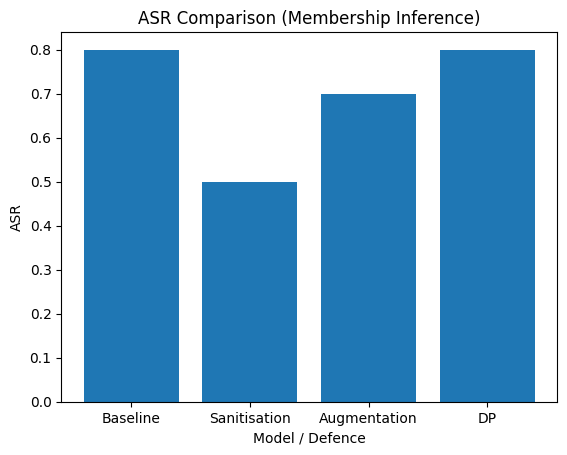

In [ ]:
import matplotlib.pyplot as plt

labels = ["Baseline", "Sanitisation", "Augmentation", "DP"]
ASR_values = [ASR, ASR_san, ASR_aug, ASR_dp]

plt.figure()
plt.bar(labels, ASR_values)

plt.title("ASR Comparison (Membership Inference)")
plt.xlabel("Model / Defence")
plt.ylabel("ASR")

plt.show()